<a href="https://colab.research.google.com/github/nsnarayanam/ConcurContext-Bank/blob/main/CSAPI_LiveML_Pipeline_Colab_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
!pip install requests
!python csapi_bootstrap.py


XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
  OGC CSAPI Bootstrap -- Auto-Discovery Script
  Server : https://os4csapi-osh.duckdns.org/sensorhub/api
  Time   : 2026-03-05T05:13:08.147042+00:00
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

  1. SERVER HEALTH CHECK
  V Server reachable
  Title      : Connected Systems API Service
  Description: N/A

  2. SYSTEMS (Sensor Nodes)

  System: Sensor Employment Team (SET-A)
    ID       : 040g
    UID      : urn:os4csapi:system:set:ft-huachuca:001
    Location : 31.6381, -110.2525

  System: Monitoring Site Node 1
    ID       : 0410
    UID      : urn:os4csapi:system:monitoring-site-node:ft-huachuca:001
    Location : 31.6384, -110.2526

  System: Relay / Repeater 001
    ID       : 041g
    UID      : urn:os4csapi:system:relay:vhf-repeater:ft-huachuca:001
    Location : 31.6429, -110.2555

  System: ODAS Mic Array Node AZ-MA-1
    ID       : 0420
    UID      : urn:os4csapi:system:odas:az-ma-1
    Location :

In [27]:
with open('csapi_bootstrap.py', 'w') as f:
    f.write('''
import requests
import json
from datetime import datetime, timezone

BASE    = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH    = ("os4csapi", "ogc134mm")
HEADERS = {"Accept": "application/json"}

def get(path, params=None):
    try:
        r = requests.get(
            f"{BASE}{path}",
            auth=AUTH,
            headers=HEADERS,
            params=params,
            timeout=15
        )
        r.raise_for_status()
        return r.json()
    except requests.exceptions.ConnectionError:
        print(f"  X Cannot connect to server. Is the simulator running?")
        return {}
    except requests.exceptions.HTTPError as e:
        print(f"  X HTTP {e.response.status_code} on {path}")
        return {}
    except Exception as e:
        print(f"  X Error on {path}: {e}")
        return {}

def section(title):
    width = 60
    print()
    print("=" * width)
    print("  " + title)
    print("=" * width)

def check_server():
    section("1. SERVER HEALTH CHECK")
    data = get("/")
    if data:
        print(f"  V Server reachable")
        print(f"  Title      : {data.get('title', 'N/A')}")
        print(f"  Description: {data.get('description', 'N/A')}")
        return True
    else:
        print("  X Server unreachable -- the data simulator may be paused.")
        print("    Check: https://ogc-csapi-explorer.pages.dev (Smoke Test tab)")
        return False

def discover_systems():
    section("2. SYSTEMS (Sensor Nodes)")
    data = get("/systems", params={"limit": 50})
    items = data.get("items", [])

    if not items:
        print("  No systems found.")
        return []

    results = []
    for s in items:
        sid   = s.get("id", "?")
        name  = s.get("properties", {}).get("name", "Unnamed")
        uid   = s.get("properties", {}).get("uid", "")
        geom  = s.get("geometry")
        coords = geom.get("coordinates", []) if geom else []
        loc = f"{coords[1]:.4f}, {coords[0]:.4f}" if len(coords) >= 2 else "no location"

        print()
        print(f"  System: {name}")
        print(f"    ID       : {sid}")
        print(f"    UID      : {uid}")
        print(f"    Location : {loc}")

        results.append({"id": sid, "name": name, "uid": uid, "location": loc})

    return results

def discover_datastreams(systems):
    section("3. DATASTREAMS (Data Channels per Sensor)")

    all_ds = get("/datastreams", params={"limit": 100}).get("items", [])

    results = []
    seen = set()

    def print_ds(d, prefix=""):
        did   = d.get("id", "?")
        if did in seen:
            return
        seen.add(did)

        name  = d.get("properties", {}).get("name", d.get("name", "Unnamed"))
        fmt   = d.get("properties", {}).get("outputName", d.get("outputName", ""))
        live  = d.get("properties", {}).get("live", d.get("live", False))
        obs_t = d.get("properties", {}).get("resultType", d.get("resultType", ""))

        print()
        print(f"  {prefix}Datastream: {name}")
        print(f"    ID         : {did}")
        print(f"    Output     : {fmt}")
        print(f"    Result Type: {obs_t}")
        print(f"    Live       : {live}")

        results.append({
            "id": did, "name": name,
            "outputName": fmt, "live": live
        })

    for sys in systems:
        sid   = sys["id"]
        sname = sys["name"]
        print()
        print(f"  --- {sname} ({sid}) ---")
        ds_data = get(f"/systems/{sid}/datastreams", params={"limit": 50})
        for d in ds_data.get("items", []):
            print_ds(d, prefix="  ")

    print()
    print(f"  --- All global datastreams ---")
    for d in all_ds:
            print_ds(d)

    return results

def discover_deployments():
    section("4. DEPLOYMENTS")
    data = get("/deployments", params={"limit": 50})
    items = data.get("items", [])

    results = []
    if not items:
        print("  No deployments found.")
        return results

    for dep in items:
        did   = dep.get("id", "?")
        name  = dep.get("properties", {}).get("name", "Unnamed")
        start = dep.get("properties", {}).get("validTime", {})
        print()
        print(f"  Deployment: {name}")
        print(f"    ID    : {did}")
        print(f"    Time  : {start}")
        results.append({"id": did, "name": name})

    return results

def sample_observations(datastreams):
    section("5. SAMPLE OBSERVATIONS (latest 3 per datastream)")

    samples = {}
    for ds in datastreams[:8]:
        did  = ds["id"]
        name = ds["name"]
        data = get(
            f"/datastreams/{did}/observations",
            params={"limit": 3, "f": "application/json"}
        )
        items = data.get("items", [])
        if items:
            print()
            print(f"  Datastream: {name} ({did})")
            for obs in items:
                t      = obs.get("phenomenonTime", obs.get("resultTime", "?"))
                result = obs.get("result", "?")
                result_str = json.dumps(result)
                if len(result_str) > 80:
                    result_str = result_str[:77] + "..."
                print(f"    [{t}]  {result_str}")
            samples[did] = items
        else:
            print()
            print(f"  Datastream: {name} ({did})  -> no recent observations")

    return samples

def save_ids(systems, datastreams, deployments):
    section("6. SAVED REFERENCE - csapi_ids.json")

    output = {
        "generated_at": datetime.now(timezone.utc).isoformat(),
        "server": BASE,
        "auth": {"username": "os4csapi", "password": "ogc134mm"},
        "systems": systems,
        "datastreams": datastreams,
        "deployments": deployments,
        "quick_copy": {
            "# Paste these into your integration scripts": "",
            "BASE": BASE,
            "AUTH_USER": "os4csapi",
            "AUTH_PASS": "ogc134mm",
            "system_ids":      [s["id"] for s in systems],
            "datastream_ids":  [d["id"] for d in datastreams],
            "deployment_ids":  [d["id"] for d in deployments],
        }
    }

    fname = "csapi_ids.json"
    with open(fname, "w") as f:
        json.dump(output, f, indent=2)

    print()
    print(f"  V Saved to: {fname}")
    print()
    print(f'  QUICK COPY -- paste into your scripts:')
    print(f'  BASE            = "{BASE}"')
    print(f'  AUTH             = ("os4csapi", "ogc134mm")')
    print(f"  SYSTEM_IDS       = {json.dumps([s['id'] for s in systems])}")
    print(f"  DATASTREAM_IDS  = {json.dumps([d['id'] for d in datastreams])}")


def print_next_steps(datastreams):
    section("7. WHAT TO DO NEXT")
    print("""
  You now have all your IDs. Here's your next steps:

  A) STREAM LIVE DATA (Python):
  -----------------------------
  import sseclient, requests, json

  DS_ID = "<paste a datastream ID from above>"
  url   = f"{BASE}/datastreams/{DS_ID}/observations"
  r     = requests.get(url, auth=AUTH, stream=True,
              params={"live": "true"},
              headers={"Accept": "text/event-stream"})

  for event in sseclient.SSEClient(r).events():
      print(json.loads(event.data))


  B) STREAM LIVE DATA (JavaScript WebSocket):
  --------------------------------------------
  const ws = new WebSocket(
    `wss://os4csapi-osh.duckdns.org/sensorhub/api`
    + `/datastreams/<DS_ID>/observations?live=true`
  );
  ws.onmessage = (e) => console.log(JSON.parse(e.data));


  C) PLOT ON MAP (Leaflet):
  --------------------------
  See csapi_integration_guide.docx - Section 3


  D) REGISTER YOUR OWN SENSOR:
  ------------------------------
  See csapi_integration_guide.docx - Section 4


  E) FEEDBACK:
  -------------
  https://github.com/OS4CSAPI/os4csapi-meta/discussions/37
    """)


if __name__ == "__main__":
    print()
    print("X" * 60)
    print("  OGC CSAPI Bootstrap -- Auto-Discovery Script")
    print("  Server : " + BASE)
    print("  Time   : " + datetime.now(timezone.utc).isoformat())
    print("X" * 60)

    alive = check_server()
    if not alive:
        print()
        print("  Run this script again when the simulator is active.")
        exit(1)

    systems     = discover_systems()
    datastreams = discover_datastreams(systems)
    deployments = discover_deployments()
    sample_observations(datastreams)
    save_ids(systems, datastreams, deployments)
    print_next_steps(datastreams)

    print()
    print("X" * 60)
    print("  Bootstrap complete. Check csapi_ids.json for all IDs.")
    print("X" * 60)
    print()
''')


In [30]:
datastream_ids = [ds['id'] for ds in datastreams]
print("Discovered Datastream IDs:")
for ds_id in datastream_ids:
    print(ds_id)

Discovered Datastream IDs:
044g
0430
04dg
043g
04c0
0440
0410
041g
042g
0450
04e0
045g
04cg
046g
0470
047g
0480
048g
04eg
0490
04d0
04a0
04ag
04b0
04bg
04f0


In [33]:
import requests, json

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

DS_IDS = [
    "044g","0430","04dg","043g","04c0","0440","0410","041g","042g","0450",
    "04e0","045g","04cg","046g","0470","047g","0480","048g","04eg","0490",
    "04d0","04a0","04ag","04b0","04bg","04f0"
]

print("ID      | NAME                          | SAMPLE RESULT")
print("-" * 80)

for did in DS_IDS:
    # Get datastream info
    info = requests.get(BASE + "/datastreams/" + did, auth=AUTH, headers=HDR).json()
    # Temporarily print the info object to debug the name extraction
    # print(info)
    name = info.get("name", info.get("properties", {}).get("name", "unknown"))

    # Get latest observation
    obs = requests.get(
        BASE + "/datastreams/" + did + "/observations",
        auth=AUTH, headers=HDR,
        params={"limit": 1}
    ).json()

    items = obs.get("items", [])
    if items:
        result = json.dumps(items[0].get("result", "?"))
        if len(result) > 50:
            result = result[:47] + "..."
    else:
        result = "no data"

    print(f"{did:<8}| {name:<30}| {result}")

"""This will give us a clean table like:
044g    | LOB AZ-MA-1                  | {"bearing": 247.3, "ssl": 0.91}
0430    | SENREP Datastream            | {"reportType": "UAS_DETECTION"}
..."""

ID      | NAME                          | SAMPLE RESULT
--------------------------------------------------------------------------------
044g    | SENREP (Sensor Report)        | {"timestamp": 1772659854.714, "title": "C-20260...
0430    | AZ-MA-1 Classification Probabilities| {"timestamp": 1772648762.5621917, "trackId": 1,...
04dg    | AZ-MA-1 Detection Capabilities| {"timestamp": 1772648537.5526903, "trackId": 1,...
043g    | AZ-MA-1 Health                | {"timestamp": 1772648766.941407, "trackId": 1, ...
04c0    | AZ-MA-1 LOB                   | {"timestamp": 1772648537.5526903, "trackId": 1,...
0440    | AZ-MA-1 Scene Summary         | {"timestamp": 1772659854.714, "title": "C-20260...
0410    | AZ-MA-1 SSL Potential Sources | no data
041g    | AZ-MA-1 SST Tracked Sources   | no data
042g    | AZ-MA-1 Track Updates         | {"timestamp": 1772648537.5526903, "trackId": 1,...
0450    | AZ-MA-2 Classification Probabilities| no data
04e0    | AZ-MA-2 Detection Capabilities| {"timest

'This will give us a clean table like:\n044g    | LOB AZ-MA-1                  | {"bearing": 247.3, "ssl": 0.91}\n0430    | SENREP Datastream            | {"reportType": "UAS_DETECTION"}\n...'

In [34]:
import requests, json

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

# Key datastreams we care about
KEY_STREAMS = {
    "UAS Location Estimate" : "04f0",
    "AZ-MA-1 LOB"           : "04c0",
    "AZ-MA-2 LOB"           : "04cg",
    "AZ-MA-3 LOB"           : "04d0",
    "AZ-MA-1 Classification": "0430",
    "AZ-MA-1 Track Updates" : "042g",
    "AZ-MA-1 Health"        : "043g",
    "SENREP Reports"        : "044g",
}

for name, did in KEY_STREAMS.items():
    print("\n" + "="*60)
    print("  " + name + " (" + did + ")")
    print("="*60)

    obs = requests.get(
        BASE + "/datastreams/" + did + "/observations",
        auth=AUTH, headers=HDR,
        params={"limit": 3}
    ).json()

    for item in obs.get("items", []):
        t      = item.get("phenomenonTime", item.get("resultTime", "?"))
        result = item.get("result", {})
        print("  Time  :", t)
        print("  Result:", json.dumps(result, indent=4))
        print()


  UAS Location Estimate (04f0)
  Time  : 2026-03-04T18:26:06.941Z
  Result: {
    "timestamp": 1772648766.941407,
    "trackId": 1,
    "estimatedLat": 31.659255,
    "estimatedLon": -110.298009,
    "cep50_m": 0.0,
    "classification": "UAS",
    "numContributingLobs": 2,
    "contributingSensors": "AZ-MA-1,AZ-MA-2",
    "residual_m": 0.0
}

  Time  : 2026-03-04T18:26:12.074Z
  Result: {
    "timestamp": 1772648772.0741317,
    "trackId": 1,
    "estimatedLat": 31.657868,
    "estimatedLon": -110.29399,
    "cep50_m": 0.0,
    "classification": "UAS",
    "numContributingLobs": 3,
    "contributingSensors": "AZ-MA-1,AZ-MA-2,AZ-MA-3",
    "residual_m": 0.0
}

  Time  : 2026-03-04T18:26:17.109Z
  Result: {
    "timestamp": 1772648777.1097732,
    "trackId": 1,
    "estimatedLat": 31.660124,
    "estimatedLon": -110.29978,
    "cep50_m": 0.0,
    "classification": "UAS",
    "numContributingLobs": 3,
    "contributingSensors": "AZ-MA-1,AZ-MA-2,AZ-MA-3",
    "residual_m": 0.0
}


  AZ-M

In [35]:
import requests, json, time
import folium
from IPython.display import display, clear_output

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

def get_latest(ds_id):
    r = requests.get(
        BASE + "/datastreams/" + ds_id + "/observations",
        auth=AUTH, headers=HDR, params={"limit": 10}
    )
    return r.json().get("items", [])

def build_map():
    # Sensor node positions
    nodes = {
        "AZ-MA-1": (31.6490196, -110.2758537),
        "AZ-MA-2": (31.6569236, -110.2659979),
        "AZ-MA-3": (31.6569236, -110.2659979),  # update if you get real coords
    }

    m = folium.Map(location=[31.658, -110.285], zoom_start=13)

    # Plot sensor nodes
    for name, (lat, lon) in nodes.items():
        folium.CircleMarker(
            location=[lat, lon],
            radius=10,
            color="blue",
            fill=True,
            fill_color="blue",
            popup=name
        ).add_to(m)

    # Plot UAS location estimates
    uas_obs = get_latest("04f0")
    for obs in uas_obs:
        r = obs.get("result", {})
        lat = r.get("estimatedLat")
        lon = r.get("estimatedLon")
        t   = obs.get("phenomenonTime", "?")
        sensors = r.get("contributingSensors", "?")
        lobs    = r.get("numContributingLobs", "?")
        if lat and lon:
            folium.Marker(
                location=[lat, lon],
                icon=folium.Icon(color="red", icon="plane"),
                popup=f"UAS @ {t}\nSensors: {sensors}\nLOBs: {lobs}"
            ).add_to(m)

    # Plot LOBs as lines from each sensor
    for ds_id, node_pos in [("04c0", nodes["AZ-MA-1"]),
                             ("04cg", nodes["AZ-MA-2"]),
                             ("04d0", nodes["AZ-MA-3"])]:
        lob_obs = get_latest(ds_id)
        for obs in lob_obs[:3]:
            r = obs.get("result", {})
            bearing = r.get("bearingTrue")
            if bearing:
                import math
                dist = 0.05  # degrees (~5km line length)
                end_lat = node_pos[0] + dist * math.cos(math.radians(bearing))
                end_lon = node_pos[1] + dist * math.sin(math.radians(bearing))
                folium.PolyLine(
                    [node_pos, (end_lat, end_lon)],
                    color="red", weight=1.5, dash_array="6"
                ).add_to(m)

    # Plot SENREPs
    senreps = get_latest("044g")
    for obs in senreps:
        r = obs.get("result", {})
        lat = r.get("etaLat")
        lon = r.get("etaLon")
        title = r.get("title", "SENREP")
        cep   = r.get("comments", "")
        if lat and lon:
            folium.Marker(
                location=[lat, lon],
                icon=folium.Icon(color="orange", icon="flag"),
                popup=f"{title}\n{cep}"
            ).add_to(m)

    return m

# Build and show the map
print("Building live map...")
m = build_map()
display(m)
print("\nDone! Red planes = UAS positions | Blue circles = sensors | Orange flags = SENREPs")

Building live map...



Done! Red planes = UAS positions | Blue circles = sensors | Orange flags = SENREPs


In [37]:
import requests, json, time, math
import folium
from IPython.display import display, clear_output

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

def get_latest(ds_id, limit=10):
    r = requests.get(
        BASE + "/datastreams/" + ds_id + "/observations",
        auth=AUTH, headers=HDR, params={"limit": limit}
    )
    return r.json().get("items", [])

def build_map():
    nodes = {
        "AZ-MA-1": (31.6490196, -110.2758537),
        "AZ-MA-2": (31.6569236, -110.2659979),
        "AZ-MA-3": (31.6490196, -110.2659979),
    }

    m = folium.Map(location=[31.658, -110.285], zoom_start=13)

    # ── Sensor nodes
    for name, (lat, lon) in nodes.items():
        folium.CircleMarker(
            location=[lat, lon],
            radius=10, color="blue",
            fill=True, fill_color="blue",
            popup=name, tooltip=name
        ).add_to(m)

    # ── UAS track (all recent positions as a trail)
    uas_obs = get_latest("04f0", limit=20)
    track_points = []
    for obs in uas_obs:
        r = obs.get("result", {})
        lat = r.get("estimatedLat")
        lon = r.get("estimatedLon")
        t   = obs.get("phenomenonTime", "?")
        sensors = r.get("contributingSensors", "?")
        lobs    = r.get("numContributingLobs", "?")
        cep     = r.get("cep50_m", "?")
        if lat and lon:
            track_points.append((lat, lon))
            folium.CircleMarker(
                location=[lat, lon],
                radius=4, color="red",
                fill=True, fill_color="red", fill_opacity=0.4,
                tooltip=t
            ).add_to(m)

    # Draw the trail line
    if len(track_points) > 1:
        folium.PolyLine(
            track_points, color="red",
            weight=2, opacity=0.6
        ).add_to(m)

    # Latest UAS position — big marker
    if track_points:
        latest = uas_obs[0].get("result", {})
        folium.Marker(
            location=track_points[0],
            icon=folium.Icon(color="red", icon="plane"),
            popup=(
                "LATEST UAS POSITION\n"
                "Lat: " + str(latest.get("estimatedLat")) + "\n"
                "Lon: " + str(latest.get("estimatedLon")) + "\n"
                "Sensors: " + str(latest.get("contributingSensors")) + "\n"
                "LOBs: " + str(latest.get("numContributingLobs"))
            ),
            tooltip="LATEST UAS"
        ).add_to(m)

    # ── Lines of Bearing
    for ds_id, node_name in [("04c0","AZ-MA-1"),
                              ("04cg","AZ-MA-2"),
                              ("04d0","AZ-MA-3")]:
        node_pos = nodes[node_name]
        lob_obs  = get_latest(ds_id, limit=3)
        for obs in lob_obs:
            r = obs.get("result", {})
            bearing = r.get("bearingTrue")
            if bearing:
                dist    = 0.06
                end_lat = node_pos[0] + dist * math.cos(math.radians(bearing))
                end_lon = node_pos[1] + dist * math.sin(math.radians(bearing))
                folium.PolyLine(
                    [node_pos, (end_lat, end_lon)],
                    color="orange", weight=1.5,
                    dash_array="6",
                    tooltip=node_name + " LOB " + str(bearing) + "°"
                ).add_to(m)

    # ── SENREPs
    senreps = get_latest("044g", limit=5)
    for obs in senreps:
        r   = obs.get("result", {})
        lat = r.get("etaLat")
        lon = r.get("etaLon")
        if lat and lon:
            folium.Marker(
                location=[lat, lon],
                icon=folium.Icon(color="orange", icon="flag"),
                popup=r.get("title","SENREP") + "\n" + r.get("comments",""),
                tooltip=r.get("title","SENREP")
            ).add_to(m)

    return m, len(track_points), len(senreps)

# ── LIVE LOOP — runs until you stop the cell
REFRESH_SECONDS = 10
run = 0

print("Live monitor started. Stop the cell to exit.")
print("Refreshing every", REFRESH_SECONDS, "seconds...\n")

while True:
    run += 1
    now = time.strftime("%H:%M:%S")

    try:
        m, uas_count, senrep_count = build_map()
        clear_output(wait=True)
        print("CSAPI LIVE MONITOR")
        print("Refresh #" + str(run) + "  |  Time: " + now)
        print("UAS positions tracked : " + str(uas_count))
        print("SENREPs filed         : " + str(senrep_count))
        print("Refreshing every " + str(REFRESH_SECONDS) + "s — stop cell to exit")
        print("-" * 50)
        display(m)

    except Exception as e:
        clear_output(wait=True)
        print("Error on refresh #" + str(run) + ": " + str(e))
        print("Retrying in " + str(REFRESH_SECONDS) + "s...")

    time.sleep(REFRESH_SECONDS)

CSAPI LIVE MONITOR
Refresh #57  |  Time: 05:29:21
UAS positions tracked : 20
SENREPs filed         : 2
Refreshing every 10s — stop cell to exit
--------------------------------------------------


KeyboardInterrupt: 

In [38]:
import requests, json, time, csv, os
from datetime import datetime, timezone

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

# Files to save
UAS_FILE    = "uas_track.csv"
LOB_FILE    = "lob_data.csv"
SENREP_FILE = "senrep_data.csv"

# Track what we've already saved (avoid duplicates)
seen_uas    = set()
seen_lobs   = set()
seen_senrep = set()

def get_latest(ds_id, limit=20):
    try:
        r = requests.get(
            BASE + "/datastreams/" + ds_id + "/observations",
            auth=AUTH, headers=HDR, params={"limit": limit}, timeout=15
        )
        return r.json().get("items", [])
    except:
        return []

def init_csv(filename, headers):
    if not os.path.exists(filename):
        with open(filename, "w", newline="") as f:
            csv.writer(f).writerow(headers)
        print("Created: " + filename)

def append_csv(filename, row):
    with open(filename, "a", newline="") as f:
        csv.writer(f).writerow(row)

# Initialise CSV files with headers
init_csv(UAS_FILE, [
    "logged_at", "phenomenonTime",
    "trackId", "estimatedLat", "estimatedLon",
    "cep50_m", "classification",
    "numContributingLobs", "contributingSensors", "residual_m"
])

init_csv(LOB_FILE, [
    "logged_at", "phenomenonTime", "sensor",
    "trackId", "bearingTrue", "bearingStdDev",
    "sensorLat", "sensorLon", "classification"
])

init_csv(SENREP_FILE, [
    "logged_at", "phenomenonTime",
    "title", "senderId", "seqNo",
    "tgtTyp", "subTyp",
    "etaLat", "etaLon", "etaTimeZ",
    "detectTimeZ", "comments"
])

REFRESH = 10
run = 0
total_uas = total_lobs = total_senreps = 0

print("Logging started. Stop cell to finish.")
print("Saving to: " + UAS_FILE + ", " + LOB_FILE + ", " + SENREP_FILE)
print("-" * 55)

while True:
    run += 1
    now = datetime.now(timezone.utc).isoformat()
    new_uas = new_lobs = new_senrep = 0

    # ── UAS Location Estimates
    for obs in get_latest("04f0", 20):
        key = obs.get("phenomenonTime","") + str(obs.get("result",{}).get("timestamp",""))
        if key not in seen_uas:
            seen_uas.add(key)
            r = obs.get("result", {})
            append_csv(UAS_FILE, [
                now,
                obs.get("phenomenonTime",""),
                r.get("trackId",""),
                r.get("estimatedLat",""),
                r.get("estimatedLon",""),
                r.get("cep50_m",""),
                r.get("classification",""),
                r.get("numContributingLobs",""),
                r.get("contributingSensors",""),
                r.get("residual_m","")
            ])
            new_uas += 1
            total_uas += 1

    # ── LOBs from all 3 sensors
    for ds_id, sensor_name in [("04c0","AZ-MA-1"),("04cg","AZ-MA-2"),("04d0","AZ-MA-3")]:
        for obs in get_latest(ds_id, 20):
            key = sensor_name + obs.get("phenomenonTime","")
            if key not in seen_lobs:
                seen_lobs.add(key)
                r = obs.get("result", {})
                append_csv(LOB_FILE, [
                    now,
                    obs.get("phenomenonTime",""),
                    sensor_name,
                    r.get("trackId",""),
                    r.get("bearingTrue",""),
                    r.get("bearingStdDev",""),
                    r.get("sensorLat",""),
                    r.get("sensorLon",""),
                    r.get("classification","")
                ])
                new_lobs += 1
                total_lobs += 1

    # ── SENREPs
    for obs in get_latest("044g", 10):
        key = obs.get("phenomenonTime","") + str(obs.get("result",{}).get("seqNo",""))
        if key not in seen_senrep:
            seen_senrep.add(key)
            r = obs.get("result", {})
            append_csv(SENREP_FILE, [
                now,
                obs.get("phenomenonTime",""),
                r.get("title",""),
                r.get("senderId",""),
                r.get("seqNo",""),
                r.get("tgtTyp",""),
                r.get("subTyp",""),
                r.get("etaLat",""),
                r.get("etaLon",""),
                r.get("etaTimeZ",""),
                r.get("detectTimeZ",""),
                r.get("comments","")
            ])
            new_senrep += 1
            total_senreps += 1

    # Status
    print("Refresh #" + str(run) +
          "  |  +" + str(new_uas) + " UAS  +" + str(new_lobs) +
          " LOBs  +" + str(new_senrep) + " SENREPs" +
          "  |  Total: " + str(total_uas) + " / " + str(total_lobs) +
          " / " + str(total_senreps))

    time.sleep(REFRESH)

Created: uas_track.csv
Created: lob_data.csv
Created: senrep_data.csv
Logging started. Stop cell to finish.
Saving to: uas_track.csv, lob_data.csv, senrep_data.csv
-------------------------------------------------------
Refresh #1  |  +20 UAS  +60 LOBs  +2 SENREPs  |  Total: 20 / 60 / 2
Refresh #2  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #3  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #4  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #5  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #6  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #7  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #8  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #9  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #10  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #11  |  +0 UAS  +0 LOBs  +0 SENREPs  |  Total: 20 / 60 / 2
Refresh #12  |  +0 UAS  +0 LOBs  +0 SENREPs  |  To

KeyboardInterrupt: 

In [39]:
from google.colab import files
files.download("uas_track.csv")
files.download("lob_data.csv")
files.download("senrep_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

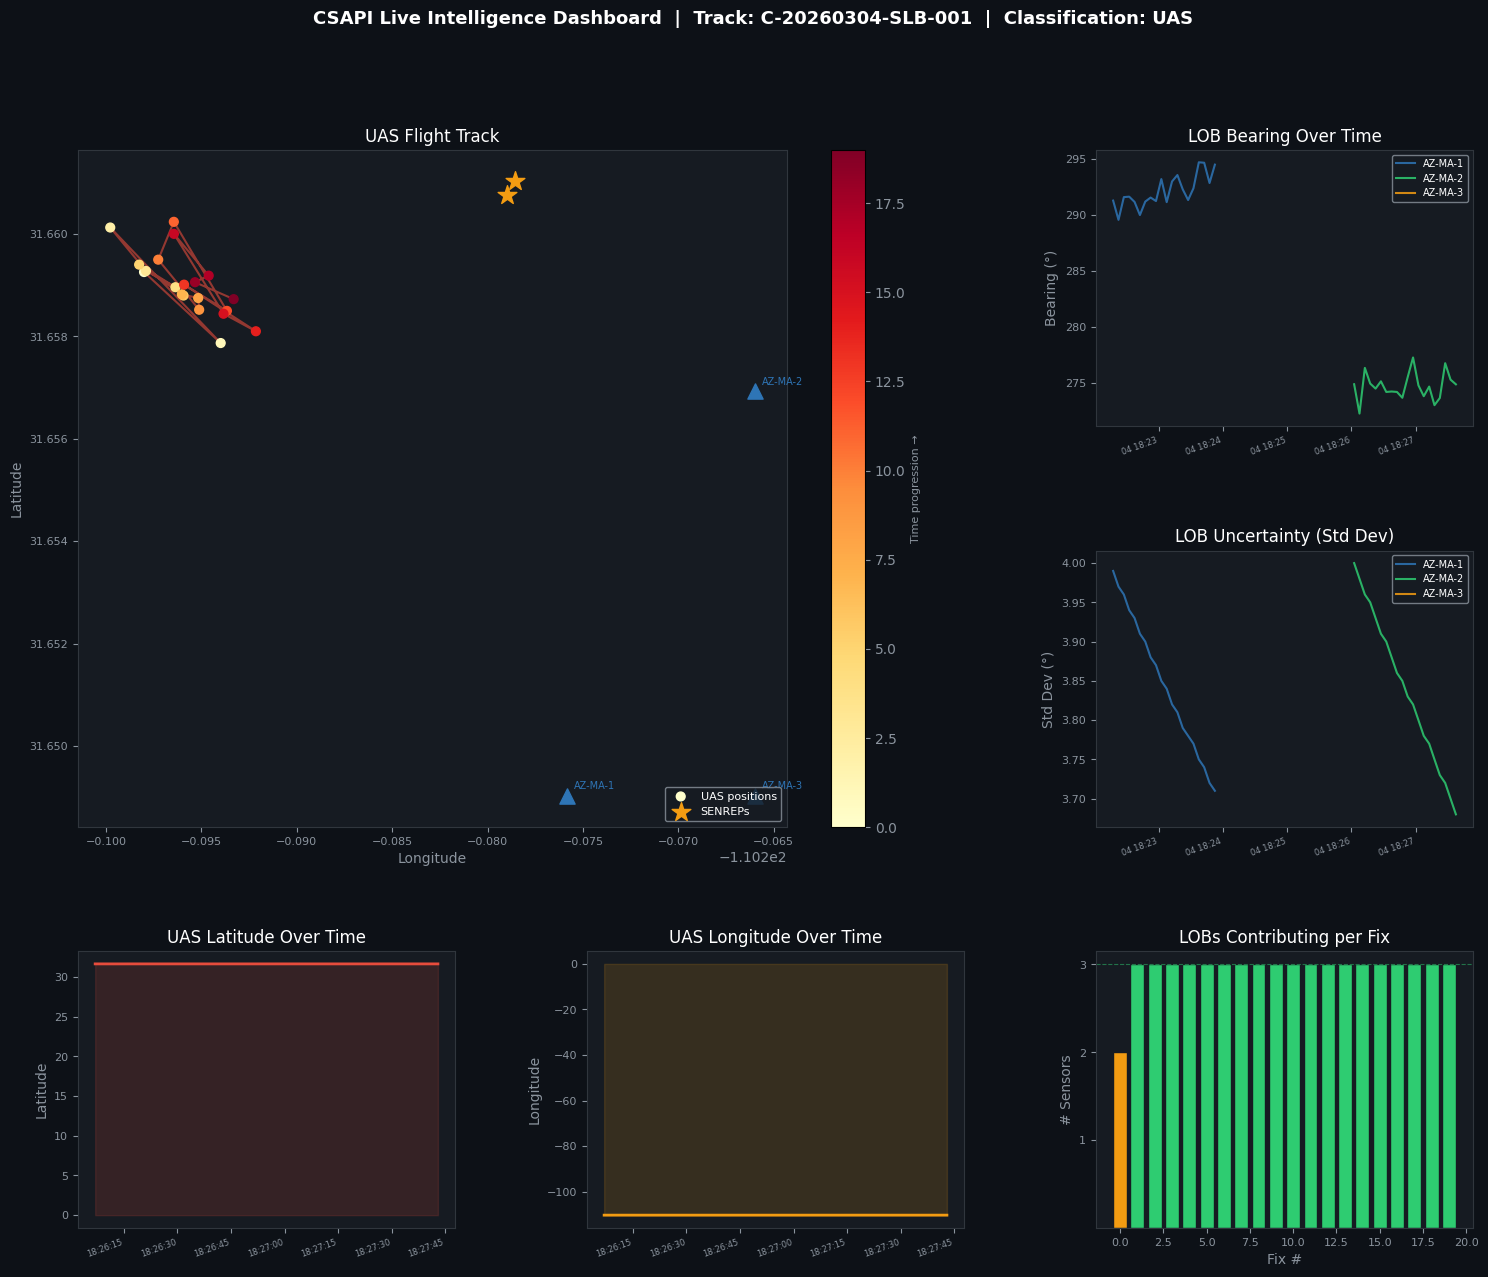

Saved: csapi_dashboard.png


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Load the CSVs
uas = pd.read_csv("uas_track.csv", parse_dates=["phenomenonTime"])
lob = pd.read_csv("lob_data.csv",  parse_dates=["phenomenonTime"])
sen = pd.read_csv("senrep_data.csv", parse_dates=["phenomenonTime"])

# Sort by time
uas = uas.sort_values("phenomenonTime").reset_index(drop=True)
lob = lob.sort_values("phenomenonTime").reset_index(drop=True)

# ── FIGURE ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK  = "#0d1117"
PANEL = "#161b22"
BLUE  = "#2E75B6"
RED   = "#e74c3c"
ORG   = "#f39c12"
GRN   = "#2ecc71"
WHT   = "#ffffff"
GRY   = "#8b949e"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=GRY, labelsize=8)
    ax.title.set_color(WHT)
    ax.title.set_fontsize(10)
    ax.title.set_fontweight("bold")
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.xaxis.label.set_color(GRY)
    ax.yaxis.label.set_color(GRY)

# ── 1. UAS FLIGHT TRACK (map view) ──────────────────────────────
ax1 = fig.add_subplot(gs[0:2, 0:2])
style_ax(ax1, "UAS Flight Track")

# Sensor nodes
sensors = {
    "AZ-MA-1": (31.6490196, -110.2758537),
    "AZ-MA-2": (31.6569236, -110.2659979),
    "AZ-MA-3": (31.6490196, -110.2659979),
}
for name, (lat, lon) in sensors.items():
    ax1.scatter(lon, lat, s=120, color=BLUE, zorder=5, marker="^")
    ax1.annotate(name, (lon, lat), textcoords="offset points",
                 xytext=(5,5), color=BLUE, fontsize=7)

# UAS trail
ax1.plot(uas["estimatedLon"], uas["estimatedLat"],
         color=RED, linewidth=1.5, alpha=0.6, zorder=3)
sc = ax1.scatter(uas["estimatedLon"], uas["estimatedLat"],
                 c=range(len(uas)), cmap="YlOrRd",
                 s=40, zorder=4, label="UAS positions")

# SENREPs
ax1.scatter(sen["etaLon"], sen["etaLat"],
            s=200, color=ORG, marker="*", zorder=6, label="SENREPs")

# Colorbar = time progression
cb = plt.colorbar(sc, ax=ax1)
cb.set_label("Time progression →", color=GRY, fontsize=8)
cb.ax.yaxis.set_tick_params(color=GRY, labelcolor=GRY)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.legend(loc="lower right", fontsize=8,
           facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)

# ── 2. BEARING OVER TIME per sensor ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2, "LOB Bearing Over Time")

colors = {"AZ-MA-1": BLUE, "AZ-MA-2": GRN, "AZ-MA-3": ORG}
for sensor, grp in lob.groupby("sensor"):
    ax2.plot(grp["phenomenonTime"], grp["bearingTrue"],
             label=sensor, color=colors.get(sensor, WHT),
             linewidth=1.5, alpha=0.85)

ax2.set_ylabel("Bearing (°)")
ax2.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 3. BEARING STD DEV (uncertainty) ──────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
style_ax(ax3, "LOB Uncertainty (Std Dev)")

for sensor, grp in lob.groupby("sensor"):
    ax3.plot(grp["phenomenonTime"], grp["bearingStdDev"],
             label=sensor, color=colors.get(sensor, WHT),
             linewidth=1.5, alpha=0.85)

ax3.set_ylabel("Std Dev (°)")
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 4. UAS LATITUDE over time ──────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4, "UAS Latitude Over Time")
ax4.plot(uas["phenomenonTime"], uas["estimatedLat"],
         color=RED, linewidth=2)
ax4.fill_between(uas["phenomenonTime"], uas["estimatedLat"],
                 alpha=0.15, color=RED)
ax4.set_ylabel("Latitude")
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 5. UAS LONGITUDE over time ──────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5, "UAS Longitude Over Time")
ax5.plot(uas["phenomenonTime"], uas["estimatedLon"],
         color=ORG, linewidth=2)
ax5.fill_between(uas["phenomenonTime"], uas["estimatedLon"],
                 alpha=0.15, color=ORG)
ax5.set_ylabel("Longitude")
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 6. CONTRIBUTING SENSORS per fix ──────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
style_ax(ax6, "LOBs Contributing per Fix")
bar_colors = [GRN if n == 3 else ORG if n == 2 else RED
              for n in uas["numContributingLobs"]]
ax6.bar(range(len(uas)), uas["numContributingLobs"],
        color=bar_colors, edgecolor=PANEL)
ax6.set_ylabel("# Sensors")
ax6.set_xlabel("Fix #")
ax6.set_yticks([1, 2, 3])
ax6.axhline(3, color=GRN, linewidth=0.8, linestyle="--", alpha=0.5)

# ── TITLE ────────────────────────────────────────────────────────
fig.suptitle(
    "CSAPI Live Intelligence Dashboard  |  Track: C-20260304-SLB-001  |  Classification: UAS",
    color=WHT, fontsize=13, fontweight="bold", y=0.98
)

plt.savefig("csapi_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved: csapi_dashboard.png")

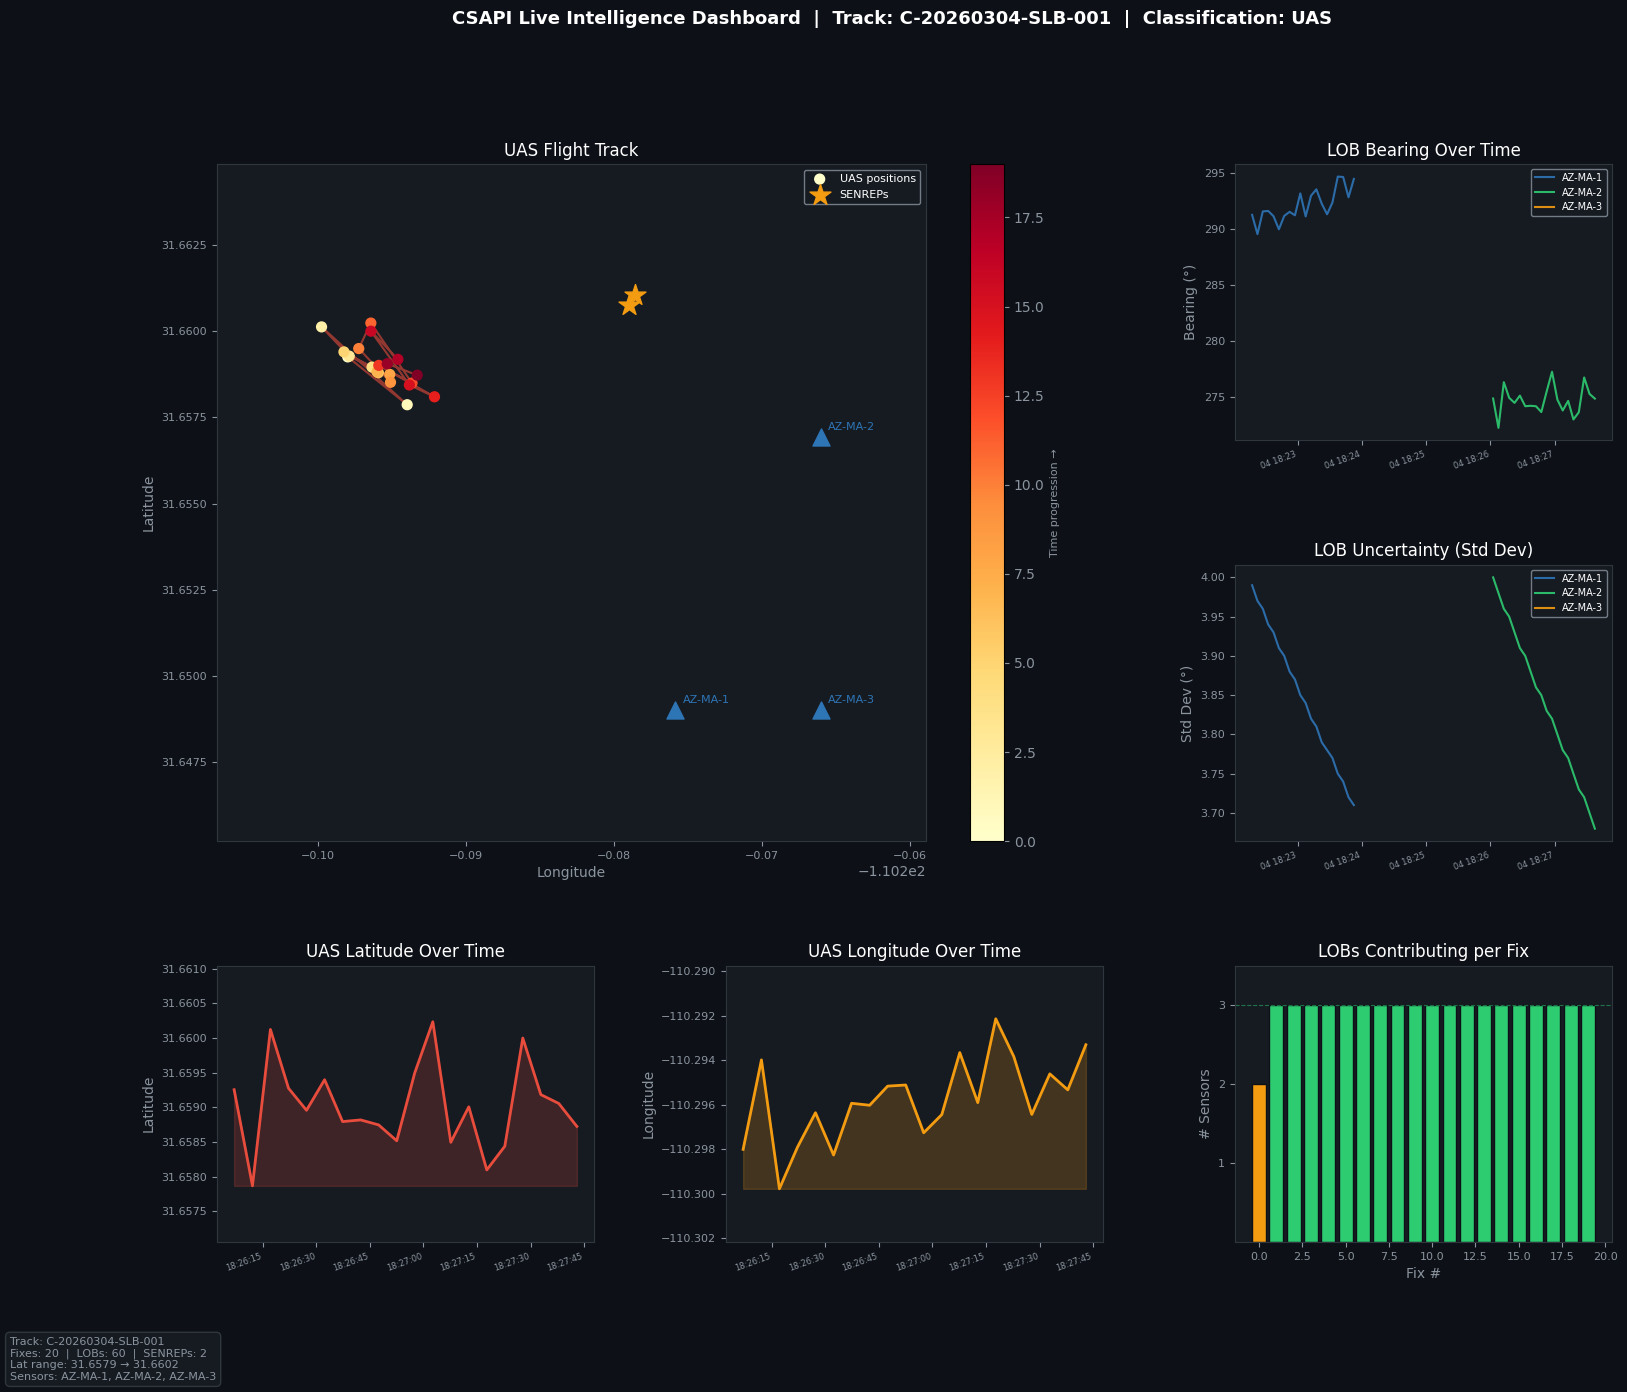

Saved: csapi_dashboard_v2.png


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

uas = pd.read_csv("uas_track.csv", parse_dates=["phenomenonTime"])
lob = pd.read_csv("lob_data.csv",  parse_dates=["phenomenonTime"])
sen = pd.read_csv("senrep_data.csv", parse_dates=["phenomenonTime"])

uas = uas.sort_values("phenomenonTime").reset_index(drop=True)
lob = lob.sort_values("phenomenonTime").reset_index(drop=True)

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor("#0d1117")
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

DARK=  "#0d1117"
PANEL= "#161b22"
BLUE=  "#2E75B6"
RED=   "#e74c3c"
ORG=   "#f39c12"
GRN=   "#2ecc71"
WHT=   "#ffffff"
GRY=   "#8b949e"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=GRY, labelsize=8)
    ax.title.set_color(WHT)
    ax.title.set_fontsize(10)
    ax.title.set_fontweight("bold")
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.xaxis.label.set_color(GRY)
    ax.yaxis.label.set_color(GRY)

# ── 1. UAS FLIGHT TRACK ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0:2, 0:2])
style_ax(ax1, "UAS Flight Track")

sensors = {
    "AZ-MA-1": (31.6490196, -110.2758537),
    "AZ-MA-2": (31.6569236, -110.2659979),
    "AZ-MA-3": (31.6490196, -110.2659979),
}
for name, (lat, lon) in sensors.items():
    ax1.scatter(lon, lat, s=150, color=BLUE, zorder=5, marker="^")
    ax1.annotate(name, (lon, lat), textcoords="offset points",
                 xytext=(5, 5), color=BLUE, fontsize=8)

ax1.plot(uas["estimatedLon"], uas["estimatedLat"],
         color=RED, linewidth=1.5, alpha=0.6, zorder=3)
sc = ax1.scatter(uas["estimatedLon"], uas["estimatedLat"],
                 c=range(len(uas)), cmap="YlOrRd",
                 s=50, zorder=4, label="UAS positions")
ax1.scatter(sen["etaLon"], sen["etaLat"],
            s=250, color=ORG, marker="*", zorder=6, label="SENREPs")

# ── FIX: tight axis limits around actual data ──
all_lons = list(uas["estimatedLon"]) + list(sen["etaLon"]) + [v[1] for v in sensors.values()]
all_lats = list(uas["estimatedLat"]) + list(sen["etaLat"]) + [v[0] for v in sensors.values()]
pad_lon = (max(all_lons) - min(all_lons)) * 0.15 + 0.002
pad_lat = (max(all_lats) - min(all_lats)) * 0.15 + 0.002
ax1.set_xlim(min(all_lons) - pad_lon, max(all_lons) + pad_lon)
ax1.set_ylim(min(all_lats) - pad_lat, max(all_lats) + pad_lat)

cb = plt.colorbar(sc, ax=ax1)
cb.set_label("Time progression →", color=GRY, fontsize=8)
cb.ax.yaxis.set_tick_params(color=GRY, labelcolor=GRY)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.legend(loc="upper right", fontsize=8,
           facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)

# ── 2. BEARING OVER TIME ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2, "LOB Bearing Over Time")
colors_s = {"AZ-MA-1": BLUE, "AZ-MA-2": GRN, "AZ-MA-3": ORG}
for sensor, grp in lob.groupby("sensor"):
    ax2.plot(grp["phenomenonTime"], grp["bearingTrue"],
             label=sensor, color=colors_s.get(sensor, WHT),
             linewidth=1.5, alpha=0.9)
ax2.set_ylabel("Bearing (°)")
ax2.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 3. BEARING STD DEV ───────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
style_ax(ax3, "LOB Uncertainty (Std Dev)")
for sensor, grp in lob.groupby("sensor"):
    ax3.plot(grp["phenomenonTime"], grp["bearingStdDev"],
             label=sensor, color=colors_s.get(sensor, WHT),
             linewidth=1.5, alpha=0.9)
ax3.set_ylabel("Std Dev (°)")
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 4. LATITUDE over time ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4, "UAS Latitude Over Time")
ax4.plot(uas["phenomenonTime"], uas["estimatedLat"], color=RED, linewidth=2)
ax4.fill_between(uas["phenomenonTime"], uas["estimatedLat"],
                 uas["estimatedLat"].min(), alpha=0.2, color=RED)
# FIX: tight y limits
lat_pad = (uas["estimatedLat"].max() - uas["estimatedLat"].min()) * 0.3 + 0.0001
ax4.set_ylim(uas["estimatedLat"].min() - lat_pad, uas["estimatedLat"].max() + lat_pad)
ax4.set_ylabel("Latitude")
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 5. LONGITUDE over time ───────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5, "UAS Longitude Over Time")
ax5.plot(uas["phenomenonTime"], uas["estimatedLon"], color=ORG, linewidth=2)
ax5.fill_between(uas["phenomenonTime"], uas["estimatedLon"],
                 uas["estimatedLon"].min(), alpha=0.2, color=ORG)
# FIX: tight y limits
lon_pad = (uas["estimatedLon"].max() - uas["estimatedLon"].min()) * 0.3 + 0.0001
ax5.set_ylim(uas["estimatedLon"].min() - lon_pad, uas["estimatedLon"].max() + lon_pad)
ax5.set_ylabel("Longitude")
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── 6. CONTRIBUTING SENSORS ──────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
style_ax(ax6, "LOBs Contributing per Fix")
bar_colors = [GRN if n == 3 else ORG if n == 2 else RED
              for n in uas["numContributingLobs"]]
ax6.bar(range(len(uas)), uas["numContributingLobs"],
        color=bar_colors, edgecolor=DARK, width=0.8)
ax6.set_ylabel("# Sensors")
ax6.set_xlabel("Fix #")
ax6.set_yticks([1, 2, 3])
ax6.set_ylim(0, 3.5)
ax6.axhline(3, color=GRN, linewidth=0.8, linestyle="--", alpha=0.5)

# ── Add a summary stats box ──────────────────────────────────────
stats = (
    "Track: C-20260304-SLB-001\n"
    "Fixes: " + str(len(uas)) + "  |  "
    "LOBs: " + str(len(lob)) + "  |  "
    "SENREPs: " + str(len(sen)) + "\n"
    "Lat range: " + str(round(uas["estimatedLat"].min(),4)) +
    " → " + str(round(uas["estimatedLat"].max(),4)) + "\n"
    "Sensors: AZ-MA-1, AZ-MA-2, AZ-MA-3"
)
fig.text(0.01, 0.01, stats, color=GRY, fontsize=8,
         verticalalignment="bottom",
         bbox=dict(facecolor=PANEL, edgecolor="#30363d", boxstyle="round,pad=0.4"))

fig.suptitle(
    "CSAPI Live Intelligence Dashboard  |  Track: C-20260304-SLB-001  |  Classification: UAS",
    color=WHT, fontsize=13, fontweight="bold", y=0.99
)

plt.savefig("csapi_dashboard_v2.png", dpi=150,
            bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved: csapi_dashboard_v2.png")

In [42]:
from google.colab import files
files.download("csapi_dashboard_v2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ── Load data ────────────────────────────────────────────────────
uas = pd.read_csv("uas_track.csv", parse_dates=["phenomenonTime"])
lob = pd.read_csv("lob_data.csv",  parse_dates=["phenomenonTime"])
uas = uas.sort_values("phenomenonTime").reset_index(drop=True)
lob = lob.sort_values("phenomenonTime").reset_index(drop=True)

# ── Feature Engineering ──────────────────────────────────────────
# 1. Speed between fixes (metres per second)
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

uas["dist_m"] = 0.0
uas["dt_s"]   = 0.0
uas["speed_ms"] = 0.0
uas["heading"] = 0.0

for i in range(1, len(uas)):
    dist = haversine(
        uas.loc[i-1,"estimatedLat"], uas.loc[i-1,"estimatedLon"],
        uas.loc[i,  "estimatedLat"], uas.loc[i,  "estimatedLon"]
    )
    dt = (uas.loc[i,"phenomenonTime"] -
          uas.loc[i-1,"phenomenonTime"]).total_seconds()
    uas.loc[i, "dist_m"]   = dist
    uas.loc[i, "dt_s"]     = dt
    uas.loc[i, "speed_ms"] = dist / dt if dt > 0 else 0

    # Heading in degrees
    dlon = uas.loc[i,"estimatedLon"] - uas.loc[i-1,"estimatedLon"]
    dlat = uas.loc[i,"estimatedLat"] - uas.loc[i-1,"estimatedLat"]
    uas.loc[i, "heading"] = (np.degrees(np.arctan2(dlon, dlat)) + 360) % 360

# 2. Heading change (turn rate)
uas["heading_change"] = uas["heading"].diff().fillna(0).abs()
uas["heading_change"] = uas["heading_change"].apply(
    lambda x: min(x, 360-x))  # handle 359→1 wraparound

# 3. Number of contributing sensors
uas["sensor_count"] = uas["numContributingLobs"]

# 4. Rolling average speed (3-fix window)
uas["speed_rolling"] = uas["speed_ms"].rolling(3, min_periods=1).mean()

print("Features computed:")
print(uas[["phenomenonTime","speed_ms","heading","heading_change",
           "dist_m","sensor_count"]].to_string())

Features computed:
                     phenomenonTime    speed_ms     heading  heading_change      dist_m  sensor_count
0  2026-03-04 18:26:06.941000+00:00    0.000000    0.000000        0.000000    0.000000             2
1  2026-03-04 18:26:12.074000+00:00   79.966310  109.040103      109.040103  410.467068             3
2  2026-03-04 18:26:17.109000+00:00  119.701474  291.287744      177.752359  602.696923             3
3  2026-03-04 18:26:22.178000+00:00   39.595165  114.370120      176.917624  200.707893             3
4  2026-03-04 18:26:27.214000+00:00   29.855626  101.637822       12.732298  150.352933             3
5  2026-03-04 18:26:32.286000+00:00   36.768037  283.060636      178.577186  186.487484             3
6  2026-03-04 18:26:37.322000+00:00   45.704320  104.556679      178.503957  230.166956             3
7  2026-03-04 18:26:42.391000+00:00    1.743200  285.091573      179.465107    8.836282             3
8  2026-03-04 18:26:47.431000+00:00   16.209478   94.791241    

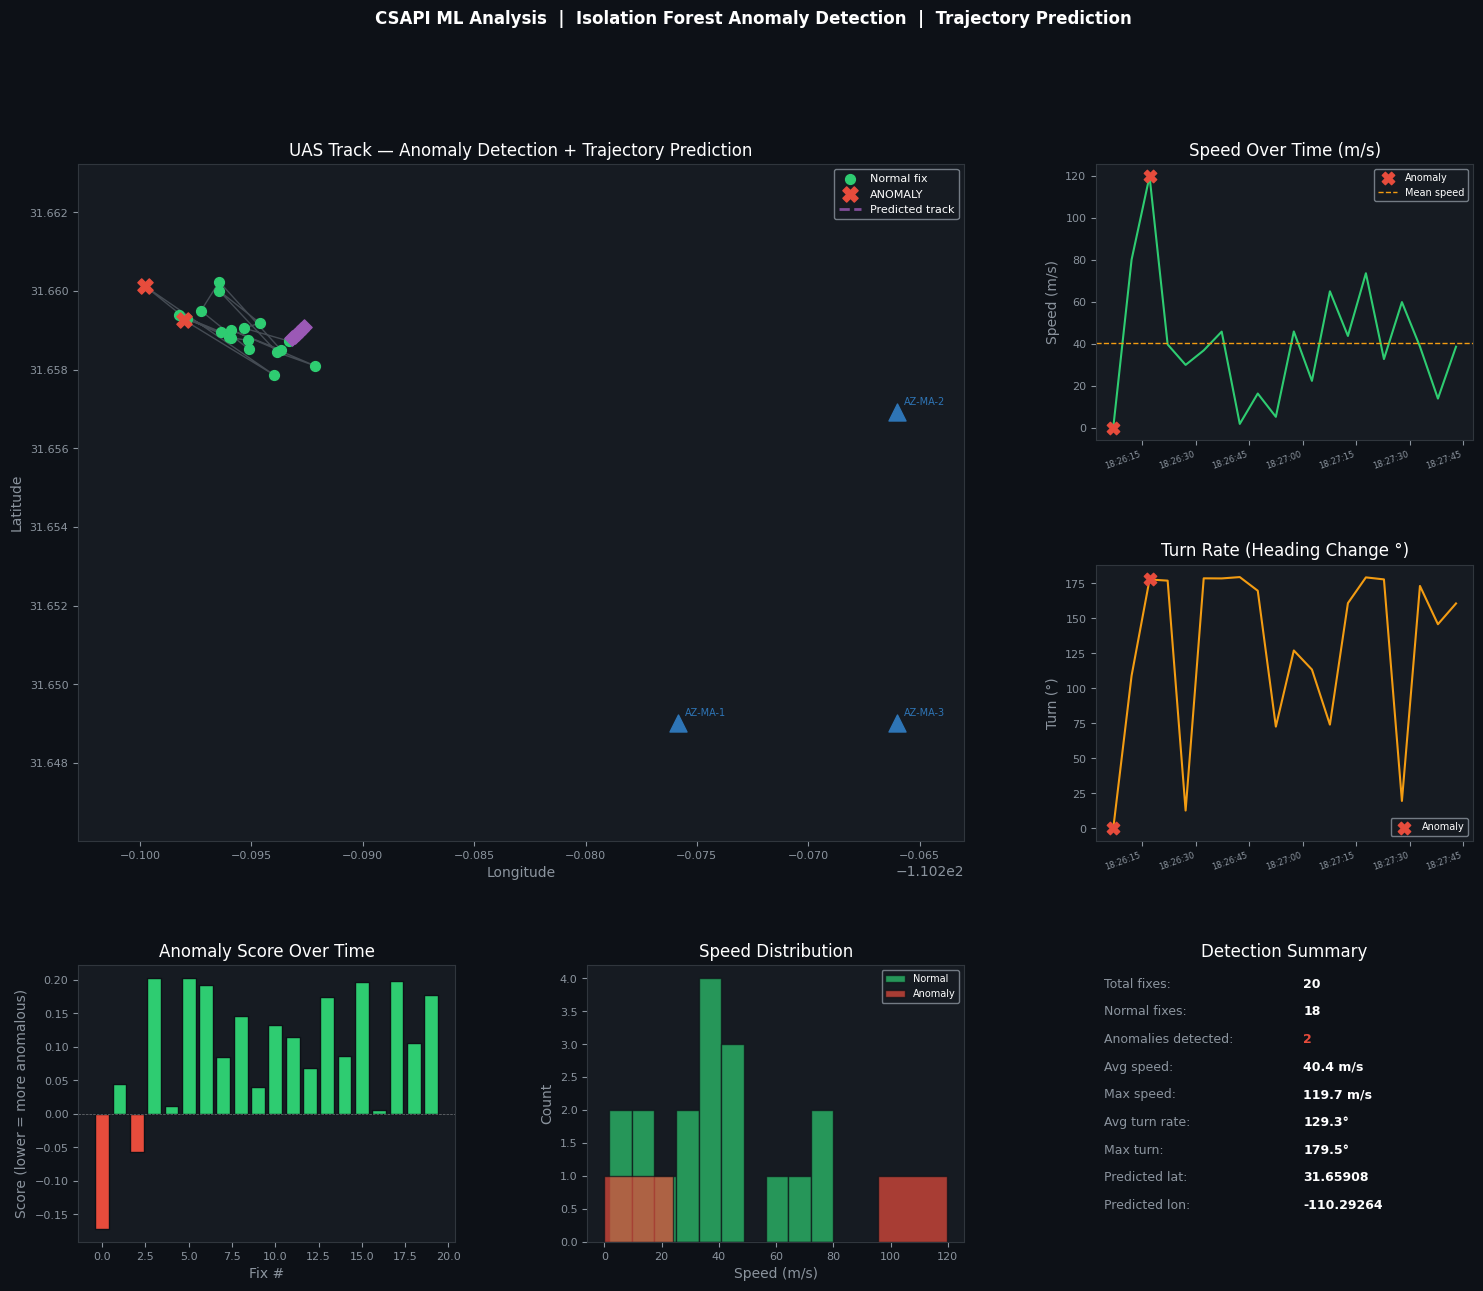

Saved: csapi_ml_dashboard.png


In [45]:
# ── Trajectory Prediction (linear extrapolation) ─────────────────
# Use last 5 fixes to predict next 5 positions
last5 = uas.tail(5).copy()
avg_dlat = last5["estimatedLat"].diff().mean()
avg_dlon = last5["estimatedLon"].diff().mean()

predicted = []
lat = uas["estimatedLat"].iloc[-1]
lon = uas["estimatedLon"].iloc[-1]
for i in range(1, 6):
    lat += avg_dlat
    lon += avg_dlon
    predicted.append((lat, lon))

pred_df = pd.DataFrame(predicted, columns=["predLat","predLon"])

# ── Anomaly Detection (Isolation Forest) ─────────────────────────
features = uas[["speed_ms", "heading_change", "sensor_count"]].copy()
# Handle potential NaN values, e.g., from diff() on first row
features = features.fillna(0)

# Scale features for IsolationForest
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Isolation Forest Model
model = IsolationForest(random_state=42, contamination=0.1) # Assuming 10% anomalies
uas["anomaly"] = model.fit_predict(scaled_features)
uas["anomaly_score"] = model.decision_function(scaled_features)

# Separate normal and anomalous fixes
anomalies = uas[uas["anomaly"] == -1]
normal    = uas[uas["anomaly"] == 1]

# ── ML DASHBOARD ─────────────────────────────────────────────────
DARK=  "#0d1117"; PANEL= "#161b22"
BLUE=  "#2E75B6"; RED=   "#e74c3c"
ORG=   "#f39c12"; GRN=   "#2ecc71"
WHT=   "#ffffff"; GRY=   "#8b949e"
PRP=   "#9b59b6"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=GRY, labelsize=8)
    ax.title.set_color(WHT)
    ax.title.set_fontsize(10)
    ax.title.set_fontweight("bold")
    ax.set_title(title)
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.xaxis.label.set_color(GRY)
    ax.yaxis.label.set_color(GRY)

fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor(DARK)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Panel 1: Track + Anomalies + Prediction ──────────────────────
ax1 = fig.add_subplot(gs[0:2, 0:2])
style_ax(ax1, "UAS Track — Anomaly Detection + Trajectory Prediction")

# Normal fixes
ax1.scatter(normal["estimatedLon"], normal["estimatedLat"],
            color=GRN, s=50, zorder=4, label="Normal fix")
# Anomalous fixes
ax1.scatter(anomalies["estimatedLon"], anomalies["estimatedLat"],
            color=RED, s=120, marker="X", zorder=5, label="ANOMALY")
# Track line
ax1.plot(uas["estimatedLon"], uas["estimatedLat"],
         color=GRY, linewidth=1, alpha=0.4, zorder=3)
# Predicted positions
ax1.plot(pred_df["predLon"], pred_df["predLat"],
         color=PRP, linewidth=2, linestyle="--",
         alpha=0.8, zorder=4, label="Predicted track")
ax1.scatter(pred_df["predLon"], pred_df["predLat"],
            color=PRP, s=60, marker="D", zorder=5)

# Arrow showing direction
ax1.annotate("",
    xy=(pred_df["predLon"].iloc[-1], pred_df["predLat"].iloc[-1]),
    xytext=(uas["estimatedLon"].iloc[-1], uas["estimatedLat"].iloc[-1]),
    arrowprops=dict(arrowstyle="->", color=PRP, lw=2))

# Sensor nodes
sensors = {
    "AZ-MA-1": (31.6490196, -110.2758537),
    "AZ-MA-2": (31.6569236, -110.2659979),
    "AZ-MA-3": (31.6490196, -110.2659979),
}
for name, (lat, lon) in sensors.items():
    ax1.scatter(lon, lat, s=150, color=BLUE, zorder=5, marker="^")
    ax1.annotate(name, (lon, lat), textcoords="offset points",
                 xytext=(5,5), color=BLUE, fontsize=7)

all_lons = (list(uas["estimatedLon"]) + list(pred_df["predLon"]) +
            [v[1] for v in sensors.values()])
all_lats = (list(uas["estimatedLat"]) + list(pred_df["predLat"]) +
            [v[0] for v in sensors.values()])
pad = 0.003
ax1.set_xlim(min(all_lons)-pad, max(all_lons)+pad)
ax1.set_ylim(min(all_lats)-pad, max(all_lats)+pad)
ax1.legend(loc="upper right", fontsize=8,
           facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# ── Panel 2: Speed over time ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
style_ax(ax2, "Speed Over Time (m/s)")
ax2.plot(uas["phenomenonTime"], uas["speed_ms"],
         color=GRN, linewidth=1.5)
ax2.scatter(anomalies["phenomenonTime"], anomalies["speed_ms"],
            color=RED, s=80, marker="X", zorder=5, label="Anomaly")
ax2.axhline(uas["speed_ms"].mean(), color=ORG, linestyle="--",
            linewidth=1, label="Mean speed")
ax2.set_ylabel("Speed (m/s)")
ax2.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── Panel 3: Heading change ───────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
style_ax(ax3, "Turn Rate (Heading Change °)")
ax3.plot(uas["phenomenonTime"], uas["heading_change"],
         color=ORG, linewidth=1.5)
ax3.scatter(anomalies["phenomenonTime"], anomalies["heading_change"],
            color=RED, s=80, marker="X", zorder=5, label="Anomaly")
ax3.set_ylabel("Turn (°)")
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=20, ha="right", fontsize=6)

# ── Panel 4: Anomaly score ────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
style_ax(ax4, "Anomaly Score Over Time")
colors_a = [RED if a == -1 else GRN for a in uas["anomaly"]]
ax4.bar(range(len(uas)), uas["anomaly_score"],
        color=colors_a, edgecolor=DARK, width=0.8)
ax4.axhline(0, color=WHT, linewidth=0.5, linestyle="--", alpha=0.4)
ax4.set_xlabel("Fix #")
ax4.set_ylabel("Score (lower = more anomalous)")

# ── Panel 5: Speed histogram ──────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
style_ax(ax5, "Speed Distribution")
ax5.hist(normal["speed_ms"], bins=10, color=GRN,
         alpha=0.7, label="Normal", edgecolor=DARK)
ax5.hist(anomalies["speed_ms"], bins=5, color=RED,
         alpha=0.7, label="Anomaly", edgecolor=DARK)
ax5.set_xlabel("Speed (m/s)")
ax5.set_ylabel("Count")
ax5.legend(fontsize=7, facecolor=PANEL, labelcolor=WHT, edgecolor=GRY)

# ── Panel 6: Summary stats ────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2])
style_ax(ax6, "Detection Summary")
ax6.axis("off")

avg_speed  = round(uas["speed_ms"].mean(), 2)
max_speed  = round(uas["speed_ms"].max(), 2)
avg_turn   = round(uas["heading_change"].mean(), 1)
max_turn   = round(uas["heading_change"].max(), 1)
n_anom     = len(anomalies)
pred_lat   = round(pred_df["predLat"].iloc[-1], 5)
pred_lon   = round(pred_df["predLon"].iloc[-1], 5)

summary = [
    ("Total fixes",        str(len(uas))),
    ("Normal fixes",       str(len(normal))),
    ("Anomalies detected", str(n_anom)),
    ("Avg speed",          str(avg_speed) + " m/s"),
    ("Max speed",          str(max_speed) + " m/s"),
    ("Avg turn rate",      str(avg_turn) + "°"),
    ("Max turn",           str(max_turn) + "°"),
    ("Predicted lat",      str(pred_lat)),
    ("Predicted lon",      str(pred_lon)),
]

for i, (label, value) in enumerate(summary):
    y = 0.92 - i * 0.10
    ax6.text(0.02, y, label + ":", color=GRY,
             fontsize=9, transform=ax6.transAxes)
    color = RED if "Anomal" in label and n_anom > 0 else WHT
    ax6.text(0.55, y, value, color=color,
             fontsize=9, fontweight="bold", transform=ax6.transAxes)

fig.suptitle(
    "CSAPI ML Analysis  |  Isolation Forest Anomaly Detection  |  Trajectory Prediction",
    color=WHT, fontsize=12, fontweight="bold", y=0.99
)

plt.savefig("csapi_ml_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=DARK)
plt.show()
print("Saved: csapi_ml_dashboard.png")

In [46]:
import requests, json, time, math
import numpy as np
import pandas as pd
import folium
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from IPython.display import display, clear_output
from datetime import datetime, timezone

BASE = "https://os4csapi-osh.duckdns.org/sensorhub/api"
AUTH = ("os4csapi", "ogc134mm")
HDR  = {"Accept": "application/json"}

def get_latest(ds_id, limit=30):
    try:
        r = requests.get(
            BASE + "/datastreams/" + ds_id + "/observations",
            auth=AUTH, headers=HDR,
            params={"limit": limit}, timeout=15
        )
        return r.json().get("items", [])
    except:
        return []

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin((phi2-phi1)/2)**2 +
         np.cos(phi1)*np.cos(phi2)*np.sin(np.radians((lon2-lon1))/2)**2)
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))

def build_features(uas):
    uas = uas.sort_values("phenomenonTime").reset_index(drop=True)
    uas["dist_m"] = 0.0
    uas["speed_ms"] = 0.0
    uas["heading"] = 0.0
    for i in range(1, len(uas)):
        dist = haversine(
            uas.loc[i-1,"estimatedLat"], uas.loc[i-1,"estimatedLon"],
            uas.loc[i,  "estimatedLat"], uas.loc[i,  "estimatedLon"]
        )
        dt = (uas.loc[i,"phenomenonTime"] -
              uas.loc[i-1,"phenomenonTime"]).total_seconds()
        uas.loc[i,"dist_m"]   = dist
        uas.loc[i,"speed_ms"] = dist/dt if dt > 0 else 0
        dlon = uas.loc[i,"estimatedLon"] - uas.loc[i-1,"estimatedLon"]
        dlat = uas.loc[i,"estimatedLat"] - uas.loc[i-1,"estimatedLat"]
        uas.loc[i,"heading"] = (np.degrees(np.arctan2(dlon,dlat))+360)%360
    uas["heading_change"] = (uas["heading"].diff()
                             .fillna(0).abs()
                             .apply(lambda x: min(x, 360-x)))
    uas["sensor_count"] = uas["numContributingLobs"]
    return uas

def run_ml(uas):
    if len(uas) < 5:
        return uas, pd.DataFrame(), pd.DataFrame()
    features = ["speed_ms","heading_change","dist_m","sensor_count"]
    X = uas[features].fillna(0)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    iso = IsolationForest(contamination=0.15, random_state=42)
    uas["anomaly"]       = iso.fit_predict(X_scaled)
    uas["anomaly_score"] = iso.decision_function(X_scaled)
    anomalies = uas[uas["anomaly"] == -1]
    normal    = uas[uas["anomaly"] ==  1]
    return uas, anomalies, normal

def predict_track(uas, steps=5):
    last5    = uas.tail(5)
    avg_dlat = last5["estimatedLat"].diff().mean()
    avg_dlon = last5["estimatedLon"].diff().mean()
    lat = uas["estimatedLat"].iloc[-1]
    lon = uas["estimatedLon"].iloc[-1]
    pts = []
    for _ in range(steps):
        lat += avg_dlat
        lon += avg_dlon
        pts.append((lat, lon))
    return pts

def build_live_map(uas, anomalies, normal, pred, lob_obs, senreps):
    sensors = {
        "AZ-MA-1": (31.6490196, -110.2758537),
        "AZ-MA-2": (31.6569236, -110.2659979),
        "AZ-MA-3": (31.6490196, -110.2659979),
    }
    m = folium.Map(location=[31.659, -110.290], zoom_start=14)

    # Sensor nodes
    for name, (lat, lon) in sensors.items():
        folium.CircleMarker([lat,lon], radius=10,
            color="blue", fill=True, fill_color="blue",
            tooltip=name).add_to(m)

    # Normal track
    if len(normal) > 1:
        folium.PolyLine(
            list(zip(uas["estimatedLat"], uas["estimatedLon"])),
            color="gray", weight=1, opacity=0.5).add_to(m)

    # Normal fixes
    for _, row in normal.iterrows():
        folium.CircleMarker(
            [row["estimatedLat"], row["estimatedLon"]],
            radius=5, color="green", fill=True,
            tooltip="Normal | " + str(round(row["speed_ms"],1)) + " m/s"
        ).add_to(m)

    # Anomalous fixes
    for _, row in anomalies.iterrows():
        folium.Marker(
            [row["estimatedLat"], row["estimatedLon"]],
            icon=folium.Icon(color="red", icon="exclamation-sign"),
            tooltip="ANOMALY | speed=" + str(round(row["speed_ms"],1)) +
                    " m/s | turn=" + str(round(row["heading_change"],1)) + "°"
        ).add_to(m)

    # Latest UAS position
    latest = uas.iloc[-1]
    folium.Marker(
        [latest["estimatedLat"], latest["estimatedLon"]],
        icon=folium.Icon(color="red", icon="plane"),
        tooltip="LATEST UAS FIX"
    ).add_to(m)

    # Predicted track
    if pred:
        pred_latlons = [[p[0],p[1]] for p in pred]
        last_pos = [uas["estimatedLat"].iloc[-1],
                    uas["estimatedLon"].iloc[-1]]
        folium.PolyLine(
            [last_pos] + pred_latlons,
            color="purple", weight=2,
            dash_array="8", opacity=0.8,
            tooltip="Predicted trajectory"
        ).add_to(m)
        folium.Marker(
            pred_latlons[-1],
            icon=folium.Icon(color="purple", icon="flag"),
            tooltip="Predicted position"
        ).add_to(m)

    # LOBs
    for obs in lob_obs[:5]:
        r = obs.get("result",{})
        bearing = r.get("bearingTrue")
        slat    = r.get("sensorLat")
        slon    = r.get("sensorLon")
        if bearing and slat and slon:
            dist    = 0.05
            end_lat = slat + dist*math.cos(math.radians(bearing))
            end_lon = slon + dist*math.sin(math.radians(bearing))
            folium.PolyLine(
                [[slat,slon],[end_lat,end_lon]],
                color="orange", weight=1.5,
                dash_array="6",
                tooltip="LOB " + str(bearing) + "°"
            ).add_to(m)

    # SENREPs
    for obs in senreps:
        r = obs.get("result",{})
        if r.get("etaLat") and r.get("etaLon"):
            folium.Marker(
                [r["etaLat"], r["etaLon"]],
                icon=folium.Icon(color="orange", icon="flag"),
                tooltip=r.get("title","SENREP")
            ).add_to(m)

    return m

# ── LIVE LOOP ─────────────────────────────────────────────────────
REFRESH = 10
run = 0
prev_anomaly_count = 0
prev_senrep_count  = 0

print("Live ML Monitor started. Stop cell to exit.")

while True:
    run += 1
    now = datetime.now(timezone.utc).strftime("%H:%M:%S")

    try:
        # Fetch data
        uas_raw  = get_latest("04f0", 30)
        lob_raw  = get_latest("04c0", 10)
        sen_raw  = get_latest("044g", 5)

        if len(uas_raw) < 5:
            clear_output(wait=True)
            print("Waiting for data... (need 5+ fixes)")
            time.sleep(REFRESH)
            continue

        # Build dataframe
        records = []
        for obs in uas_raw:
            r = obs.get("result",{})
            r["phenomenonTime"] = pd.to_datetime(obs.get("phenomenonTime"))
            records.append(r)
        uas_df = pd.DataFrame(records)

        # Run ML
        uas_df, anomalies, normal = run_ml(build_features(uas_df))
        pred = predict_track(uas_df)

        # ── ALERTS ───────────────────────────────────────────────
        new_anomalies = len(anomalies) - prev_anomaly_count
        new_senreps   = len(sen_raw)   - prev_senrep_count

        alert_msg = ""
        if new_anomalies > 0:
            alert_msg += "🚨 ANOMALY DETECTED! " + str(new_anomalies) + " new anomalous fix(es)!  "
        if new_senreps > 0:
            alert_msg += "🚩 NEW SENREP FILED!"

        prev_anomaly_count = len(anomalies)
        prev_senrep_count  = len(sen_raw)

        # Build map
        m = build_live_map(uas_df, anomalies, normal, pred, lob_raw, sen_raw)

        # Display
        clear_output(wait=True)
        latest = uas_df.iloc[-1]
        avg_spd = round(uas_df["speed_ms"].mean(), 1)

        print("═" * 55)
        print("  CSAPI LIVE ML MONITOR  |  " + now)
        print("═" * 55)
        print("  UAS fixes     : " + str(len(uas_df)))
        print("  Anomalies     : " + str(len(anomalies)) +
              (" ⚠️" if len(anomalies) > 0 else " ✅"))
        print("  Avg speed     : " + str(avg_spd) + " m/s")
        print("  Latest pos    : " + str(round(latest["estimatedLat"],5)) +
              ", " + str(round(latest["estimatedLon"],5)))
        print("  Predicted pos : " + str(round(pred[0][0],5)) +
              ", " + str(round(pred[0][1],5)))
        print("  SENREPs filed : " + str(len(sen_raw)))
        if alert_msg:
            print("\n  " + alert_msg)
        print("═" * 55)
        print("  Refreshing every " + str(REFRESH) + "s — stop cell to exit")

        display(m)

    except Exception as e:
        clear_output(wait=True)
        print("Error on refresh #" + str(run) + ": " + str(e))

    time.sleep(REFRESH)

═══════════════════════════════════════════════════════
  CSAPI LIVE ML MONITOR  |  06:29:46
═══════════════════════════════════════════════════════
  UAS fixes     : 30
  Anomalies     : 5 ⚠️
  Avg speed     : 41.9 m/s
  Latest pos    : 31.66036, -110.29404
  Predicted pos : 31.6607, -110.29439
  SENREPs filed : 2
═══════════════════════════════════════════════════════
  Refreshing every 10s — stop cell to exit


KeyboardInterrupt: 